# Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

In [2]:
import glob
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate, StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin
from tools.viz.rc_style import rc_context_talk


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed

import numpy as np

In [3]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    "M103_2026_02_18_15_30",
    # "M106_2026_02_25_15_00",
]
all_sess_no_drop = {}
for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess, std=0.03)
    all_sess_no_drop[sess] = td

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).


In [4]:
perturb_td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

/tmp/ipykernel_1125552/3882025568.py:1: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)


In [135]:
for area in Params.areas:
    pr = dim.pca_pr(np.concatenate(perturb_td[f'{area}_rates'].values))
    print(f'{area}: {pr}')

MOp: 30.64162744314666
SSp: 43.45459944206909
CP: 45.93710486468124
VAL: 21.12799979532457


In [5]:
pc_dict = {
    "MOp": 30,
    "SSp": 25,
    "CP": 30,
    "VAL": 40,
}
td_potent_null = perturb_td_shuff.copy()
for area_a in Params.areas:
    for area_b in Params.areas:
        if area_b == area_a:
            continue
        td_potent_null = subspaces.compute_potent_null_td(
            td_=td_potent_null,
            signal_x=f'{area_a}_rates_pca',
            signal_y=f'{area_b}_rates_pca',
            origin_rank=pc_dict[area_a],
            target_rank=pc_dict[area_a],
            n_iter=2,
            window=(200, 350),
            thresh=0.027
        )

Computing MOp_rates_pca -> SSp_rates_pca potent and null subspaces
Prediction R2 = 0.2719. Optimal rank: 10
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0631
	Iter: 2. Prediction R2 = 0.0046
Iteration number: 2. R2 below 0.027, breaking
	Final Prediction R2 = 0.0046
Diagnostics:
	Total MOp_rates_pca var:         12480.16
	Fraction Potent (dim: 10) var:    0.338
	Fraction Null (dim: 10) var:      0.137
	Fraction Null init var:          0.287
	Fraction MOp_rates_pca var:      0.625
Computing MOp_rates_pca -> CP_rates_pca potent and null subspaces
Prediction R2 = 0.2841. Optimal rank: 10
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0575
	Iter: 2. Prediction R2 = 0.0062
Iteration number: 2. R2 below 0.027, breaking
	Final Prediction R2 = 0.0062
Diagnostics:
	Total MOp_rates_pca var:         12480.16
	Fraction Potent (dim: 10) var:    0.202
	Fraction Null (dim: 10) var:      0.199
	Fraction Null init var:          0.423
	Fraction MOp_rates_pca var:      0.625
Computing MOp_rates_p

In [210]:
from scipy.ndimage import uniform_filter1d

def regression_classification_avg_window(
    X: np.ndarray,
    y: np.ndarray,
    model=Ridge(0.01),
    max_time_bin=400,
    step_bin=2,
    window_length_bin=20,
    # scorer=decode.get_custom_scorer(),
    scorer=make_scorer(r2_score),
    cv=5,
    bin_size=0.01,
    min_time_bin=125,
) -> tuple:
    """Run moving-window regression of neural activity on perturbation strength.

    Returns
    -------
    scores    : ndarray (time × cv_folds)
    times_s   : ndarray  time axis in seconds
    rise_time : float    first post-perturbation time where smoothed mean R²
                         exceeds rise_chance + 2*mean_fold_std for
                         min_rise_bins consecutive bins (nan if never reached)
    """
    r2_scores = []
    if max_time_bin is None:
        max_time_bin = X.shape[1]

    for t in tqdm(
        np.arange(min_time_bin, max_time_bin + 1 - window_length_bin, step=step_bin)
    ):
        X_ = X[:, t : t + window_length_bin, :]
        n_trials, n_time, n_feat = X_.shape
        r2 = cross_val_score(
            model,
            # X_.reshape(-1, n_time*n_feat),
            X_.mean(1),
            y,
            scoring=scorer,
            cv=cv,
        )
        r2_scores.append(r2)

    scores  = np.array(r2_scores)   # (time × cv_folds)
    times_s = np.arange(min_time_bin + window_length_bin, max_time_bin + 1, step_bin) * bin_size
    return scores, times_s-2


In [57]:
np.arange(125, 400 + 1 - 20, step=2)
np.arange(125 + 20, 400 + 1, 2) * 0.01

array([1.45, 1.47, 1.49, 1.51, 1.53, 1.55, 1.57, 1.59, 1.61, 1.63, 1.65,
       1.67, 1.69, 1.71, 1.73, 1.75, 1.77, 1.79, 1.81, 1.83, 1.85, 1.87,
       1.89, 1.91, 1.93, 1.95, 1.97, 1.99, 2.01, 2.03, 2.05, 2.07, 2.09,
       2.11, 2.13, 2.15, 2.17, 2.19, 2.21, 2.23, 2.25, 2.27, 2.29, 2.31,
       2.33, 2.35, 2.37, 2.39, 2.41, 2.43, 2.45, 2.47, 2.49, 2.51, 2.53,
       2.55, 2.57, 2.59, 2.61, 2.63, 2.65, 2.67, 2.69, 2.71, 2.73, 2.75,
       2.77, 2.79, 2.81, 2.83, 2.85, 2.87, 2.89, 2.91, 2.93, 2.95, 2.97,
       2.99, 3.01, 3.03, 3.05, 3.07, 3.09, 3.11, 3.13, 3.15, 3.17, 3.19,
       3.21, 3.23, 3.25, 3.27, 3.29, 3.31, 3.33, 3.35, 3.37, 3.39, 3.41,
       3.43, 3.45, 3.47, 3.49, 3.51, 3.53, 3.55, 3.57, 3.59, 3.61, 3.63,
       3.65, 3.67, 3.69, 3.71, 3.73, 3.75, 3.77, 3.79, 3.81, 3.83, 3.85,
       3.87, 3.89, 3.91, 3.93, 3.95, 3.97, 3.99])

  drop_trials_sem_crosses_zero: by SEM: 292  |  by value: 423  |  kept: 291/424 (68.6%)


  0%|          | 0/128 [00:00<?, ?it/s]

100%|██████████| 128/128 [00:00<00:00, 199.49it/s]


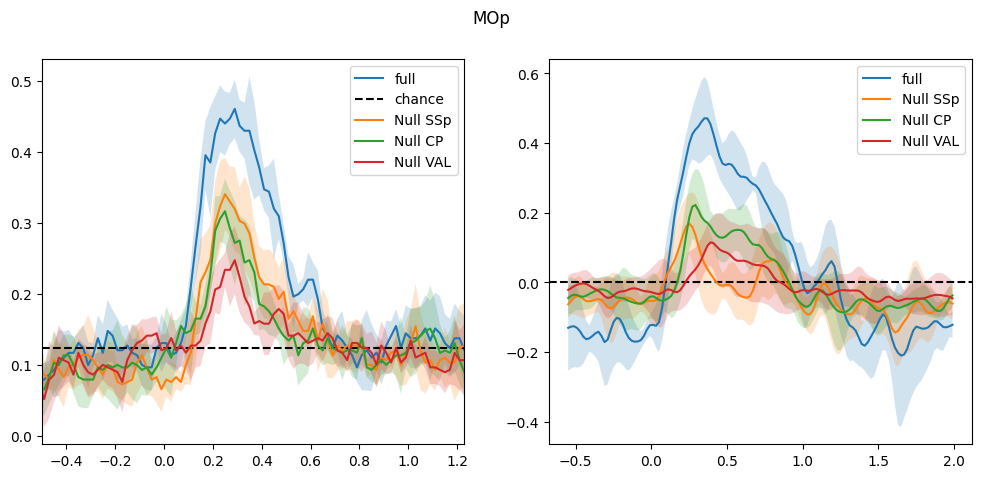

In [225]:
n_splits = 5
shuffle = True

cv_dir = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=42)
cv_dist = KFold(n_splits=n_splits, shuffle=shuffle, random_state=42)
window_length_bin = 20

######## Dropping #############
td_drop = dsp.drop_trials_sem_crosses_zero(td_potent_null_vm, std=False)
y_dir   = np.array(td_drop.values_Sol_direction.values.tolist())
y_dist  = td_drop.disturb_sum.values.astype(float)
_, _counts = np.unique(y_dir, return_counts=True)
chance  = _counts.max() / _counts.sum() 

for area_a in Params.areas[:1]:
    X = np.stack(td_drop[f'{area_a}_rates_pca'])[:, :, :pc_dict[area_a]]
    acc, times = regression_classification_avg_window(
            X,
            y_dir,
            model=GaussianNB(),
            window_length_bin=window_length_bin,
            step_bin=2,
            cv=cv_dir,
            scorer='accuracy'
        )
    r2, times = regression_classification_avg_window(
        X,
        y_dist,
        model=Ridge(0.01, solver='svd'),
        window_length_bin=window_length_bin,
        step_bin=2,
        cv=cv_dist
    )
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    ax = axs[0]
    ax_dist = axs[1]

    vizutils.shaded_errorbar(ax, times, acc, label='full')
    vizutils.shaded_errorbar(ax_dist, times, r2, label='full')
    ax.axhline(chance, color='k', ls='--', label='chance')
    ax_dist.axhline(0, color='k', ls='--')

    plt.suptitle(area_a)
    

    for area_b in Params.areas:
        if area_b == area_a:
            continue

        X = np.stack(td_drop[f'{area_a}_rates_pca_null_{area_b}_rates_pca'])
        acc, times = regression_classification_avg_window(
            X,
            y_dir,
            model=GaussianNB(),
            window_length_bin=window_length_bin,
            step_bin=2,
            cv=cv_dir,
            scorer='accuracy'
        )
        r2, times = regression_classification_avg_window(
            X,
            y_dist,
            model=Ridge(0.01, solver='svd'),
            window_length_bin=window_length_bin,
            step_bin=2,
            cv=cv_dist
        )
        vizutils.shaded_errorbar(ax, times, acc, label=f'Null {area_b}')
        vizutils.shaded_errorbar(ax_dist, times, r2, label=f'Null {area_b}')

    
    ax.legend()
    ax.set_xlim(-0.5, 1.23)
    ax_dist.legend()
    plt.show()


In [15]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, KFold

area_x = 'MOp'
area_y = 'CP'
n_splits = 5
shuffle = True
cv_dir = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=42)
cv_dist = KFold(n_splits=n_splits, shuffle=shuffle, random_state=42)


td_drop = dsp.drop_trials_sem_crosses_zero(td_potent_null, std=False)
td_drop.loc[:, 'power'] = td_drop.apply(
        lambda row: row['power'][row["concat_perturb_time"] - 200:row["concat_perturb_time"] + 301, :],
        axis=1
    )
y_dir   = np.array(td_drop.values_Sol_direction.values.tolist())
y_dist  = td_drop.disturb_sum.values.astype(float)
_, _counts = np.unique(y_dir, return_counts=True)
chance  = _counts.max() / _counts.sum() 



shuffle=False
alpha=0.01
window = (200, 250)

full_arr = np.stack(td_drop[f'{area_x}_rates_pca'].values)[:, window[0]:window[1], :pc_dict[area_x]]
full_arr = full_arr.mean(1)

potent_arr = np.stack(td_drop[f'{area_x}_rates_pca_potent_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
potent_arr = potent_arr.mean(1)

null_arr = np.stack(td_drop[f'{area_x}_rates_pca_null_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
null_arr = null_arr.mean(1)

rng = np.random.default_rng(seed=42)
perm = rng.permutation(td_drop.disturb_sum.values.shape[0])

# Disturbance decoding
r2s_full    = cross_val_score(Ridge(alpha), full_arr,   y_dist, scoring=make_scorer(r2_score), cv=cv_dist)
r2s_potent  = cross_val_score(Ridge(alpha), potent_arr, y_dist, scoring=make_scorer(r2_score), cv=cv_dist)
r2s_null    = cross_val_score(Ridge(alpha), null_arr,   y_dist, scoring=make_scorer(r2_score), cv=cv_dist)

print(f'Disturbance — full: {r2s_full.mean():.4f}  potent: {r2s_potent.mean():.4f}  null: {r2s_null.mean():.4f}')


full_arr = np.stack(td_drop[f'{area_x}_rates_pca'].values)[:, window[0]:window[1], :pc_dict[area_x]]
# full_arr = full_arr.reshape(full_arr.shape[0], -1)
full_arr = full_arr.mean(1)

potent_arr = np.stack(td_drop[f'{area_x}_rates_pca_potent_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
# potent_arr = potent_arr.reshape(potent_arr.shape[0], -1)
potent_arr = potent_arr.mean(1)

null_arr = np.stack(td_drop[f'{area_x}_rates_pca_null_{area_y}_rates_pca'].values)[:, window[0]:window[1], :]
# null_arr = null_arr.reshape(null_arr.shape[0], -1)
null_arr = null_arr.mean(1)

# Direction decoding

perm_dir = rng.permutation(y_dir.shape[0])
r2s_full_dir    = cross_val_score(LinearDiscriminantAnalysis(), full_arr,   y_dir, scoring='accuracy', cv=cv_dir)
r2s_potent_dir  = cross_val_score(LinearDiscriminantAnalysis(), potent_arr, y_dir, scoring='accuracy', cv=cv_dir)
r2s_null_dir    = cross_val_score(LinearDiscriminantAnalysis(), null_arr,   y_dir, scoring='accuracy', cv=cv_dir)

print(f'Direction     — full: {r2s_full_dir.mean():.4f}  potent: {r2s_potent_dir.mean():.4f}  null: {r2s_null_dir.mean():.4f}')

  drop_trials_sem_crosses_zero: by SEM: 292  |  by value: 423  |  kept: 291/424 (68.6%)
Disturbance — full: 0.4745  potent: 0.4248  null: 0.1874
Direction     — full: 0.3917  potent: 0.2887  null: 0.2680


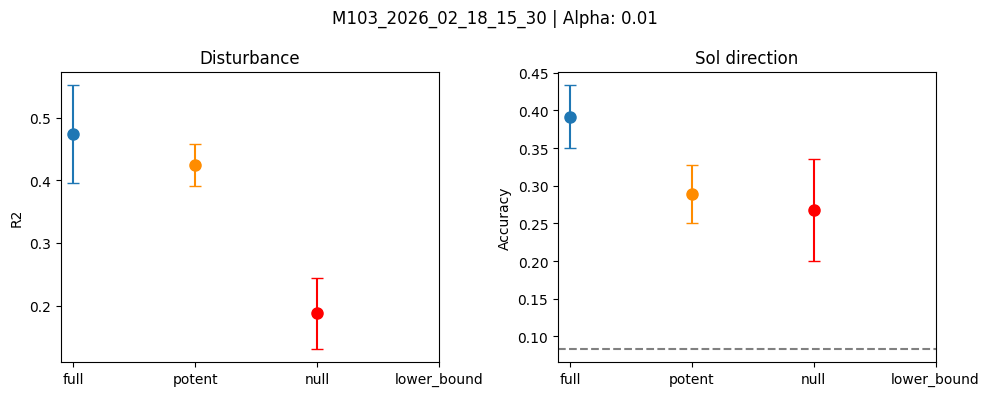

In [16]:
labels = ['full', 'potent', 'null', 'lower_bound']
clrs   = ['tab:blue', 'darkorange', 'red', 'gray']

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

data = [
    (axs[0], 'Disturbance', [r2s_full, r2s_potent, r2s_null], 'R2', ),
    (axs[1], 'Sol direction', [r2s_full_dir, r2s_potent_dir, r2s_null_dir], 'Accuracy'),
]

for ax, title, r2s_list, ylabel in data:
    for i, (lbl, r2s, c) in enumerate(zip(labels, r2s_list, clrs)):
        ax.errorbar(i, r2s.mean(), yerr=r2s.std(), color=c, fmt='o', markersize=8, capsize=4, label=lbl)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylabel=='Accuracy':
        ax.axhline(1/12, color='gray', linestyle='dashed')
plt.suptitle(f'{SESSIONS[0]} | Alpha: {alpha}')
plt.tight_layout()

## Heatmaps

In [36]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M106_2026_02_25_15_00",
]
all_sess_no_drop = {}
for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess, std=0.03)
    all_sess_no_drop[sess] = td

perturb_td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'idx_motion', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
['SSp_spikes', 'all_spikes', 'VAL_spikes', 'MOs_spikes', 'CP_spikes', 'MOp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.9003984063745% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.9003984063745% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.9003984063745% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.9003984063745% of trials
  warnings.warn(


Resulting SSp_spikes ephys data shape is (NxT): (90, 48000)
Resulting all_spikes ephys data shape is (NxT): (54, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (192, 48000)
Resulting MOs_spikes ephys data shape is (NxT): (172, 48000)
Resulting CP_spikes ephys data shape is (NxT): (151, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (83, 48000)
Skipped 107 trials
Otsu immobility threshold: 2.2837
Dropped 83 of 501 rows (16.57%).


/home/me24/repos/earthquake-analysis/notebooks/standardising/../../tools/dsp/preprocessing.py:193: RuntimeWarning: divide by zero encountered in log10
  lambda a: np.log10(np.abs(np.sum(a)))
/tmp/ipykernel_1125552/3502421279.py:19: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)


In [40]:
pc_dict = {
    "MOp": 30,  #30
    "SSp": 25,  #25
    "CP": 30,  #30
    "VAL": 45,  #40
}

# pc_dict = {
#     "MOp": 30,  #30
#     "SSp": 43,  #25
#     "CP": 45,  #30
#     "VAL": 21,  #40
# }
td_potent_null = perturb_td_shuff.copy()
for area_a in Params.areas:
    for area_b in Params.areas:
        if area_b == area_a:
            continue
        td_potent_null = subspaces.compute_potent_null_td(
            td_=td_potent_null,
            signal_x=f'{area_a}_rates_pca',
            signal_y=f'{area_b}_rates_pca',
            origin_rank=pc_dict[area_a],
            target_rank=pc_dict[area_b],
            n_iter=2,
            window=(200, 300),
            thresh=0.05
        )

Computing MOp_rates_pca -> SSp_rates_pca potent and null subspaces
Prediction R2 = 0.2423. Optimal rank: 10
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0874
	Iter: 2. Prediction R2 = 0.0145
Iteration number: 2. R2 below 0.05, breaking
	Final Prediction R2 = 0.0145
Diagnostics:
	Total MOp_rates_pca var:         6327.40
	Fraction Potent (dim: 10) var:    0.357
	Fraction Null (dim: 10) var:      0.182
	Fraction Null init var:          0.421
	Fraction MOp_rates_pca var:      0.778
Computing MOp_rates_pca -> CP_rates_pca potent and null subspaces
Prediction R2 = 0.2095. Optimal rank: 6
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.1014
	Iter: 2. Prediction R2 = 0.0372
Iteration number: 2. R2 below 0.05, breaking
	Final Prediction R2 = 0.0372
Diagnostics:
	Total MOp_rates_pca var:         6327.40
	Fraction Potent (dim: 6) var:    0.181
	Fraction Null (dim: 18) var:      0.452
	Fraction Null init var:          0.596
	Fraction MOp_rates_pca var:      0.778
Computing MOp_rates_pca -> 

In [41]:
td_potent_null_vm = subspaces.match_null_variance_to_potent(td_potent_null, Params.areas)

MOp -> SSp: null var (1148.5) <= potent var (2257.8), skipping
MOp -> CP: null var 2861.7 -> 1205.7 (potent: 1147.1) | dims 18 -> 6
MOp -> VAL: null var 3619.9 -> 1341.1 (potent: 1300.7) | dims 22 -> 5
SSp -> MOp: null var (2345.9) <= potent var (2724.8), skipping
SSp -> CP: null var 3567.5 -> 1407.2 (potent: 1503.3) | dims 19 -> 6
SSp -> VAL: null var 3185.0 -> 1968.1 (potent: 1885.8) | dims 17 -> 9
CP -> MOp: null var (3634.5) <= potent var (3730.7), skipping
CP -> SSp: null var (1918.9) <= potent var (3252.3), skipping
CP -> VAL: null var 3801.3 -> 3634.2 (potent: 3563.9) | dims 16 -> 15
VAL -> MOp: null var 12572.0 -> 4779.7 (potent: 4592.5) | dims 35 -> 11
VAL -> SSp: null var 13339.4 -> 3977.0 (potent: 3825.0) | dims 37 -> 9
VAL -> CP: null var 13445.2 -> 3695.3 (potent: 3719.3) | dims 37 -> 8


  drop_trials_sem_crosses_zero: by SEM: 296  |  by value: 364  |  kept: 296/364 (81.3%)
MOp -> SSp | dist potent: 0.530  null: 0.055 | dir potent: 0.179  null: 0.216
MOp -> CP | dist potent: 0.487  null: 0.202 | dir potent: 0.166  null: 0.209
MOp -> VAL | dist potent: 0.538  null: 0.093 | dir potent: 0.189  null: 0.172
SSp -> MOp | dist potent: 0.410  null: 0.044 | dir potent: 0.169  null: 0.112
SSp -> CP | dist potent: 0.405  null: 0.088 | dir potent: 0.118  null: 0.145
SSp -> VAL | dist potent: 0.416  null: 0.023 | dir potent: 0.125  null: 0.132
CP -> MOp | dist potent: 0.454  null: 0.153 | dir potent: 0.152  null: 0.122
CP -> SSp | dist potent: 0.472  null: -0.051 | dir potent: 0.155  null: 0.098
CP -> VAL | dist potent: 0.494  null: 0.206 | dir potent: 0.166  null: 0.098
VAL -> MOp | dist potent: 0.393  null: 0.021 | dir potent: 0.138  null: 0.155
VAL -> SSp | dist potent: 0.342  null: 0.067 | dir potent: 0.149  null: 0.159
VAL -> CP | dist potent: 0.380  null: 0.028 | dir potent: 

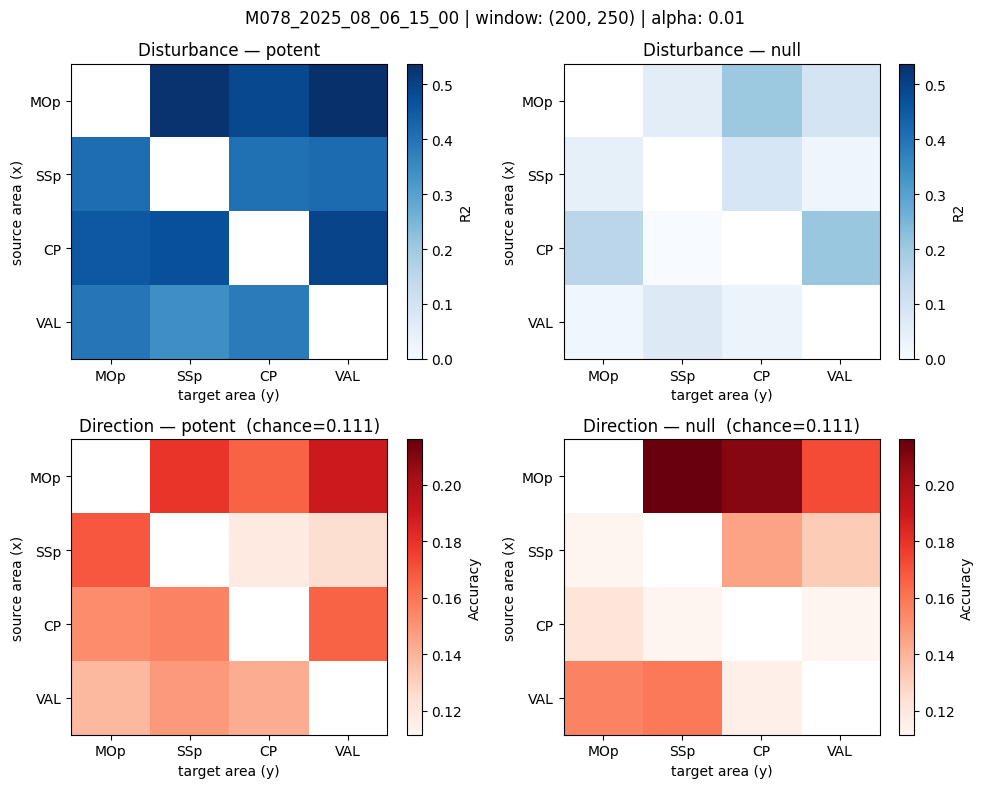

disturbance_potent:
[[       nan 0.52976456 0.48689677 0.537578  ]
 [0.40951919        nan 0.40456861 0.41554263]
 [0.45421474 0.47187592        nan 0.4944257 ]
 [0.39297837 0.3419423  0.3802576         nan]]
disturbance_null:
[[        nan  0.05528864  0.20185751  0.09296992]
 [ 0.04422209         nan  0.08750033  0.02254381]
 [ 0.15293508 -0.05144287         nan  0.2062565 ]
 [ 0.02054858  0.06738149  0.02843052         nan]]
direction_potent:
[[       nan 0.17915254 0.16559322 0.18932203]
 [0.16870056        nan 0.11813559 0.12491525]
 [0.1519209  0.15531073        nan 0.16564972]
 [0.13836158 0.14853107 0.14180791        nan]]
direction_null:
[[       nan 0.2159887  0.20943503 0.1720904 ]
 [0.11163842        nan 0.14514124 0.13169492]
 [0.12163842 0.09785311        nan 0.09813559]
 [0.15525424 0.15858757 0.11491525        nan]]


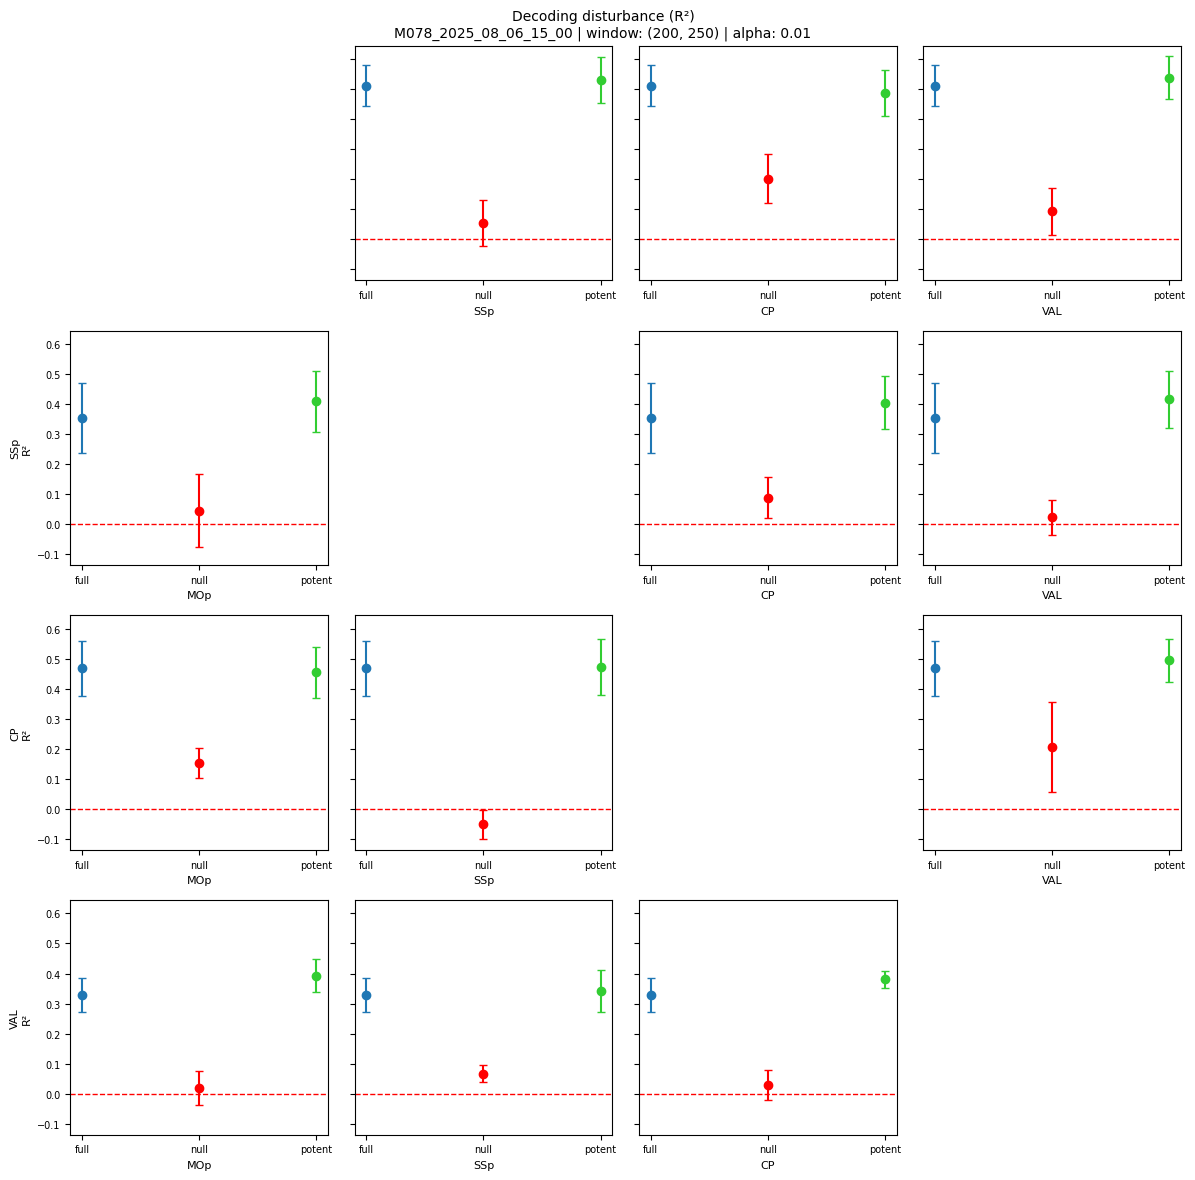

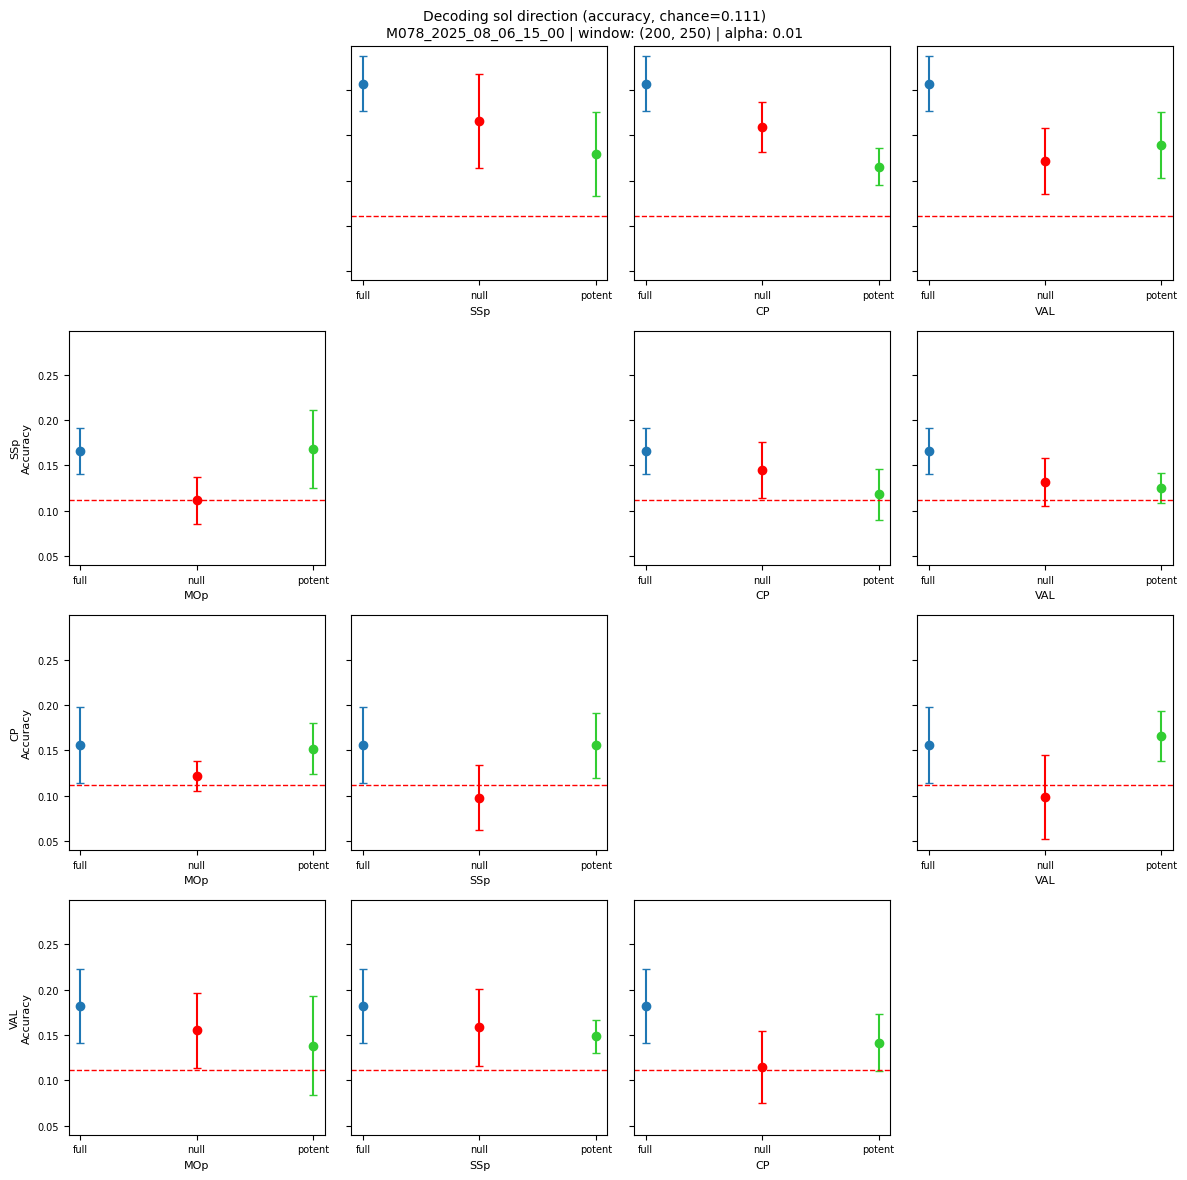

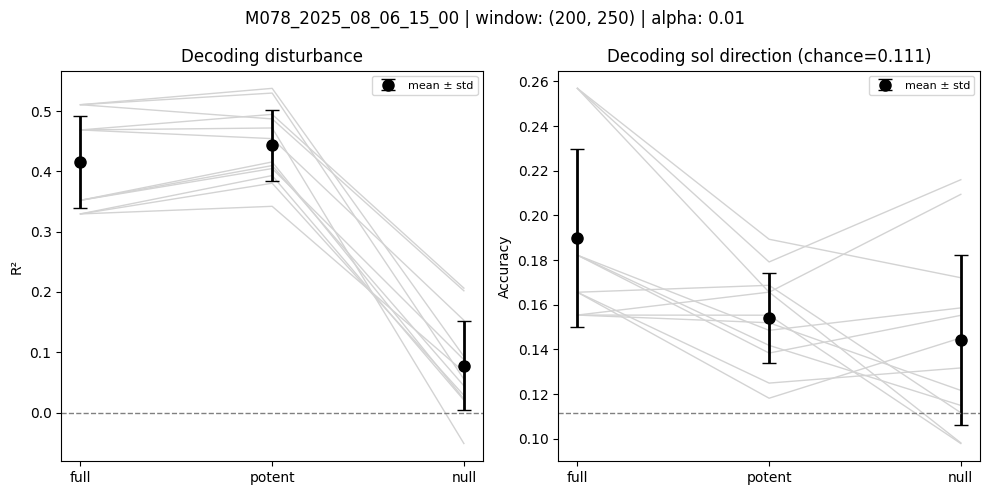

In [45]:
n_splits = 5
alpha=0.01
shuffle = True
window = (200, 250)
cv_dir = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=42)
cv_dist = KFold(n_splits=n_splits, shuffle=shuffle, random_state=42)

######## Dropping #############
# td_drop = dsp.drop_trials_sem_crosses_zero(td_potent_null, std=False)
td_drop = dsp.drop_trials_sem_crosses_zero(td_potent_null_vm, std=False)

####### Balancing #########################

# from sklearn.utils import resample

# rng_bal = np.random.default_rng(42)
# labels  = td_drop.values_Sol_direction.values
# classes, counts = np.unique(labels, return_counts=True)
# min_count = counts.min()

# print(f'Before balancing: {dict(zip(classes.astype(int), counts))}')
# print(f'Undersampling each class to {min_count} trials')

# balanced_idx = np.concatenate([
#     rng_bal.choice(np.where(labels == c)[0], size=min_count, replace=False)
#     for c in classes
# ])
# balanced_idx = np.sort(balanced_idx)

# td_drop = td_drop.iloc[balanced_idx].reset_index(drop=True)

# labels_bal = td_drop.values_Sol_direction.values
# _, counts_bal = np.unique(labels_bal, return_counts=True)
# print(f'After balancing:  {len(td_drop)} trials total, {counts_bal[0]} per class')

######################

y_dir   = np.array(td_drop.values_Sol_direction.values.tolist())
y_dist  = td_drop.disturb_sum.values.astype(float)
_, _counts = np.unique(y_dir, return_counts=True)
chance  = _counts.max() / _counts.sum()

########################################

areas = Params.areas
n_areas = len(areas)
area_idx = {a: i for i, a in enumerate(areas)}

disturbance_potent = np.full((n_areas, n_areas), np.nan)
disturbance_null   = np.full((n_areas, n_areas), np.nan)
direction_potent   = np.full((n_areas, n_areas), np.nan)
direction_null     = np.full((n_areas, n_areas), np.nan)

# Store full cv score arrays for the scatter plot
scores_dist = {}  # (area_a, area_b) -> {'full': array, 'null': array, 'potent': array}
scores_dir  = {}

for area_a in areas:
    for area_b in areas:
        if area_b == area_a:
            continue

        i, j = area_idx[area_a], area_idx[area_b]
        full_arr_ = np.stack(td_drop[f"{area_a}_rates_pca"].values)[:, window[0]:window[1], :pc_dict[area_a]]
        full_arr = full_arr_.mean(1)

        potent_arr_ = np.stack(td_drop[f"{area_a}_rates_pca_potent_{area_b}_rates_pca"].values)[:, window[0]:window[1], :]
        potent_arr = potent_arr_.mean(1)

        null_arr_ = np.stack(td_drop[f"{area_a}_rates_pca_null_{area_b}_rates_pca"].values)[:, window[0]:window[1], :]
        null_arr = null_arr_.mean(1)

        # Disturbance decoding
        r2s_full   = cross_val_score(Ridge(alpha), full_arr,   y_dist, scoring=make_scorer(r2_score), cv=cv_dist)
        r2s_potent = cross_val_score(Ridge(alpha), potent_arr, y_dist, scoring=make_scorer(r2_score), cv=cv_dist)
        r2s_null   = cross_val_score(Ridge(alpha), null_arr,   y_dist, scoring=make_scorer(r2_score), cv=cv_dist)

        # acc_full        = cross_val_score(GaussianNB(), full_arr_.reshape(full_arr_.shape[0], -1),   y_dir, scoring="accuracy", cv=cv_dir)
        acc_full        = cross_val_score(GaussianNB(), full_arr,   y_dir, scoring="accuracy", cv=cv_dir)
        # accs_potent_dir = cross_val_score(GaussianNB(), potent_arr_.reshape(potent_arr_.shape[0], -1), y_dir, scoring="accuracy", cv=cv_dir)
        accs_potent_dir = cross_val_score(GaussianNB(), potent_arr, y_dir, scoring="accuracy", cv=cv_dir)
        # accs_null_dir   = cross_val_score(GaussianNB(), null_arr_.reshape(null_arr_.shape[0], -1),   y_dir, scoring="accuracy", cv=cv_dir)
        accs_null_dir   = cross_val_score(GaussianNB(), null_arr,   y_dir, scoring="accuracy", cv=cv_dir)

        disturbance_potent[i, j] = r2s_potent.mean()
        disturbance_null[i, j]   = r2s_null.mean()
        direction_potent[i, j]   = accs_potent_dir.mean()
        direction_null[i, j]     = accs_null_dir.mean()

        scores_dist[(area_a, area_b)] = {'full': r2s_full,  'null': r2s_null,      'potent': r2s_potent}
        scores_dir[(area_a, area_b)]  = {'full': acc_full,  'null': accs_null_dir, 'potent': accs_potent_dir}

        print(f"{area_a} -> {area_b} | dist potent: {r2s_potent.mean():.3f}  null: {r2s_null.mean():.3f} | dir potent: {accs_potent_dir.mean():.3f}  null: {accs_null_dir.mean():.3f}")

# ── 2x2 heatmap ──────────────────────────────────────────────────────────────
# Shared colour limits per row
dist_vmax = np.nanmax(np.abs(np.stack([disturbance_potent, disturbance_null])))
dist_vmin = -dist_vmax

dir_vmax  = np.nanmax(np.stack([direction_potent, direction_null]))
dir_vmin  = chance

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

panels = [
    (axs[0, 0], disturbance_potent, "Disturbance — potent", "R2",       "Blues",  0, dist_vmax),
    (axs[0, 1], disturbance_null,   "Disturbance — null",   "R2",       "Blues",  0, dist_vmax),
    (axs[1, 0], direction_potent,   "Direction — potent",   "Accuracy", "Reds", dir_vmin,  dir_vmax),
    (axs[1, 1], direction_null,     "Direction — null",     "Accuracy", "Reds", dir_vmin,  dir_vmax),
]

for ax, mat, title, cbar_label, cmap, vmin, vmax in panels:
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)
    ax.set_title(title)
    ax.set_xticks(range(n_areas))
    ax.set_xticklabels(areas)
    ax.set_yticks(range(n_areas))
    ax.set_yticklabels(areas)
    ax.set_xlabel("target area (y)")
    ax.set_ylabel("source area (x)")

axs[1, 0].set_title(f"Direction — potent  (chance={chance:.3f})")
axs[1, 1].set_title(f"Direction — null  (chance={chance:.3f})")

plt.suptitle(f"{SESSIONS[0]} | window: {window} | alpha: {alpha}")
plt.tight_layout()
plt.show()

print("disturbance_potent:")
print(disturbance_potent)
print("disturbance_null:")
print(disturbance_null)
print("direction_potent:")
print(direction_potent)
print("direction_null:")
print(direction_null)

# ── scatter grids: one figure per decode target ──────────────────────────────
clrs  = {'full': 'tab:blue', 'null': 'red', 'potent': 'limegreen'}
xlbls = ['full', 'null', 'potent']
xpos  = np.arange(len(xlbls))

for title, scores, ref_line, ylabel in [
    ('Decoding disturbance (R²)',                          scores_dist, 0,   'R²'),
    (f'Decoding sol direction (accuracy, chance={chance:.3f})', scores_dir,  chance, 'Accuracy'),
]:
    fig, axs = plt.subplots(n_areas, n_areas, figsize=(n_areas * 3, n_areas * 3), sharey=True)
    fig.suptitle(f"{title}\n{SESSIONS[0]} | window: {window} | alpha: {alpha}", fontsize=10)
    for r, area_a in enumerate(areas):
        for c, area_b in enumerate(areas):
            ax = axs[r, c]
            if area_a == area_b:
                ax.set_visible(False)
                continue
            s = scores[(area_a, area_b)]
            for xi, key in enumerate(xlbls):
                ax.errorbar(xi, s[key].mean(), yerr=s[key].std(),
                            fmt='o', color=clrs[key], markersize=6, capsize=3)
            if ref_line is not None:
                ax.axhline(ref_line, color='red', linestyle='dashed', linewidth=1)
            ax.set_xticks(xpos)
            ax.set_xticklabels(xlbls, fontsize=7)
            ax.set_xlabel(area_b, fontsize=8)
            if c == 0:
                ax.set_ylabel(f"{area_a}\n{ylabel}", fontsize=8)
            ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.show()

# ── full → potent → null lines, all area pairs ───────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

xlbls = ['full', 'potent', 'null']
xpos  = np.arange(len(xlbls))

for ax, scores, ref_line, ylabel, title in [
    (axs[0], scores_dist, 0,      'R²',       'Decoding disturbance'),
    (axs[1], scores_dir,  chance, 'Accuracy', f'Decoding sol direction (chance={chance:.3f})'),
]:
    # Grey background lines per area pair (no markers)
    for s in scores.values():
        means = [s[k].mean() for k in xlbls]
        ax.plot(xpos, means, '-', color='lightgray', linewidth=1.0, zorder=1)

    # Overlay: mean ± std across all area pairs at each x position
    all_means = np.array([[s[k].mean() for k in xlbls] for s in scores.values()])
    grand_mean = all_means.mean(axis=0)
    grand_std  = all_means.std(axis=0)
    ax.errorbar(xpos, grand_mean, yerr=grand_std,
                fmt='o', color='black', markersize=8, capsize=5,
                linewidth=2, zorder=2, label='mean ± std')

    ax.axhline(ref_line, color='gray', linestyle='dashed', linewidth=1)
    ax.set_xticks(xpos)
    ax.set_xticklabels(xlbls)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle(f"{SESSIONS[0]} | window: {window} | alpha: {alpha}")
plt.tight_layout()
plt.show()


## All sessions

In [47]:
all_sess_pot_null_vm.keys()

dict_keys(['M061_2025_03_06_14_00', 'M078_2025_08_06_15_00'])

In [3]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    "M106_2026_02_25_15_00",
]
all_sess_pot_null_vm = {}
pc_dict = {
    "MOp": 30,  #30
    "SSp": 25,  #25
    "CP": 30,  #30
    "VAL": 45,  #40
}



for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess, std=0.03)
    perturb_td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)
    perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

    td_potent_null = perturb_td_shuff.copy()
    for area_a in Params.areas:
        for area_b in Params.areas:
            if area_b == area_a:
                continue
            td_potent_null = subspaces.compute_potent_null_td(
                td_=td_potent_null,
                signal_x=f'{area_a}_rates_pca',
                signal_y=f'{area_b}_rates_pca',
                origin_rank=pc_dict[area_a],
                target_rank=pc_dict[area_b],
                n_iter=2,
                window=(200, 350),
                thresh=0.06
            )
    # td_potent_null = subspaces.match_null_variance_to_potent(td_potent_null, Params.areas)
    all_sess_pot_null_vm[sess] = td_potent_null

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)
Skipped 40 trials
Otsu immobility threshold: 2.9536
Dropped 48 of 333 rows (14.41%).
Computing MOp_rates_pca -> SSp_rates_pca potent and null subspaces
Prediction R2 = 0.2758. Optimal rank: 8
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0779
	Iter: 2. Prediction R2 = 0.0123
Iteration number: 2. R2 below 0.06, breaking
	Final Prediction R2 = 0.0123
Diagnostics:
	Total MOp_rates_pca var:         14845.44
	Fraction Potent (dim: 8) var:    0.201
	Fraction Null (dim: 14) var:      0.238
	Fraction Null init var:          0.402
	Fraction MOp_rates_p

/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.9003984063745% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.9003984063745% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.9003984063745% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.9003984063745% of trials
  warnings.warn(


Resulting SSp_spikes ephys data shape is (NxT): (90, 48000)
Resulting all_spikes ephys data shape is (NxT): (54, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (192, 48000)
Resulting MOs_spikes ephys data shape is (NxT): (172, 48000)
Resulting CP_spikes ephys data shape is (NxT): (151, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (83, 48000)
Skipped 107 trials
Otsu immobility threshold: 2.2837
Dropped 83 of 501 rows (16.57%).


...

Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).


/tmp/ipykernel_1926216/3227201527.py:27: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)


Computing MOp_rates_pca -> SSp_rates_pca potent and null subspaces
Prediction R2 = 0.2918. Optimal rank: 8
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0780
	Iter: 2. Prediction R2 = 0.0101
Iteration number: 2. R2 below 0.06, breaking
	Final Prediction R2 = 0.0101
Diagnostics:
	Total MOp_rates_pca var:         12480.16
	Fraction Potent (dim: 8) var:    0.306
	Fraction Null (dim: 14) var:      0.191
	Fraction Null init var:          0.319
	Fraction MOp_rates_pca var:      0.625
Computing MOp_rates_pca -> CP_rates_pca potent and null subspaces
Prediction R2 = 0.2841. Optimal rank: 10
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0575
Iteration number: 1. R2 below 0.06, breaking
	Final Prediction R2 = 0.0575
Diagnostics:
	Total MOp_rates_pca var:         12480.16
	Fraction Potent (dim: 10) var:    0.202
	Fraction Null init var:          0.423
	Fraction MOp_rates_pca var:      0.625
Computing MOp_rates_pca -> VAL_rates_pca potent and null subspaces
Prediction R2 = 0.3463. Optimal 

/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 87 trials
Otsu immobility threshold: 2.2123
Dropped 130 of 499 rows (26.05%).
Computing MOp_rates_pca -> SSp_rates_pca potent and null subspaces
Prediction R2 = 0.3262. Optimal rank: 10
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0886
	Iter: 2. Prediction R2 = 0.0113
Iteration number: 2. R2 below 0.06, breaking
	Final Prediction R2 = 0.0113
Diagnostics:
	Total MOp_rates_pca var:         16630.14
	Fraction Potent (dim: 10) var:    0.336
	Fraction Null (dim: 10) var:      0.140
	Fraction Null init var:          0.347
	Fraction MOp_rates_pca var:      0.683
Computing MOp_rates_pca -> CP_rates_pca potent and nu

In [15]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.metrics import r2_score, make_scorer
from sklearn.naive_bayes import GaussianNB

_alpha    = 0.01
_window   = (200, 250)
_n_splits = 5
_shuffle  = True
_cv_dir   = StratifiedKFold(n_splits=_n_splits, shuffle=_shuffle, random_state=42)
_cv_dist  = KFold(n_splits=_n_splits, shuffle=_shuffle, random_state=42)

# Collect all lines across sessions
all_lines_dist = []   # each entry: (n_areas_pairs, 3) means array
all_lines_dir  = []
all_chances    = []

for sess, td_vm in all_sess_pot_null_vm.items():

    td_drop = dsp.drop_trials_sem_crosses_zero(td_vm, std=False)
    y_dir   = np.array(td_drop.values_Sol_direction.values.tolist())
    y_dist  = td_drop.disturb_sum.values.astype(float)
    _, _counts = np.unique(y_dir, return_counts=True)
    all_chances.append(_counts.max() / _counts.sum())

    for area_a in Params.areas:
        for area_b in Params.areas:
            if area_a == area_b:
                continue

            full_arr_ = np.stack(td_drop[f"{area_a}_rates_pca"].values)[:, _window[0]:_window[1], :pc_dict[area_a]]
            full_arr  = full_arr_.mean(1)

            potent_arr_ = np.stack(td_drop[f"{area_a}_rates_pca_potent_{area_b}_rates_pca"].values)[:, _window[0]:_window[1], :]
            potent_arr  = potent_arr_.mean(1)

            null_arr_ = np.stack(td_drop[f"{area_a}_rates_pca_null_{area_b}_rates_pca"].values)[:, _window[0]:_window[1], :]
            null_arr  = null_arr_.mean(1)

            r2s_full   = cross_val_score(Ridge(_alpha), full_arr,   y_dist, scoring=make_scorer(r2_score), cv=_cv_dist)
            r2s_potent = cross_val_score(Ridge(_alpha), potent_arr, y_dist, scoring=make_scorer(r2_score), cv=_cv_dist)
            r2s_null   = cross_val_score(Ridge(_alpha), null_arr,   y_dist, scoring=make_scorer(r2_score), cv=_cv_dist)

            acc_full   = cross_val_score(GaussianNB(), full_arr_.reshape(full_arr_.shape[0], -1),     y_dir, scoring="accuracy", cv=_cv_dir)
            acc_potent = cross_val_score(GaussianNB(), potent_arr_.reshape(potent_arr_.shape[0], -1), y_dir, scoring="accuracy", cv=_cv_dir)
            acc_null   = cross_val_score(GaussianNB(), null_arr_.reshape(null_arr_.shape[0], -1),     y_dir, scoring="accuracy", cv=_cv_dir)

            all_lines_dist.append([r2s_full.mean(),   r2s_potent.mean(),  r2s_null.mean()])
            all_lines_dir.append( [acc_full.mean(),   acc_potent.mean(),  acc_null.mean()])

    print(f'{sess} done')


  drop_trials_sem_crosses_zero: by SEM: 221  |  by value: 270  |  kept: 221/270 (81.9%)
M061_2025_03_06_14_00 done
  drop_trials_sem_crosses_zero: by SEM: 296  |  by value: 364  |  kept: 296/364 (81.3%)
M078_2025_08_06_15_00 done
  drop_trials_sem_crosses_zero: by SEM: 292  |  by value: 423  |  kept: 291/424 (68.6%)
M103_2026_02_18_15_30 done
  drop_trials_sem_crosses_zero: by SEM: 222  |  by value: 319  |  kept: 216/325 (66.5%)
M106_2026_02_25_15_00 done


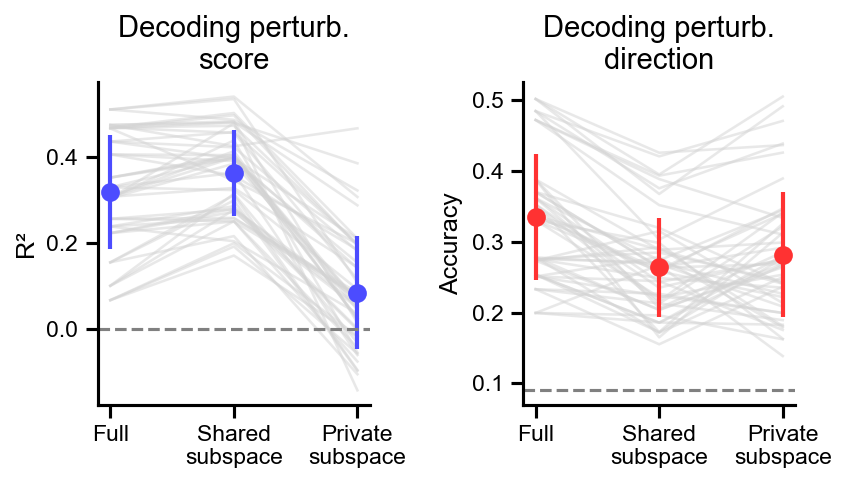

Total lines: 48 (4 sessions × 12 area pairs)


In [16]:
# ── single combined plot ──────────────────────────────────────────────────────
import matplotlib as mpl
bwr   = mpl.colormaps['bwr']
C_DIR = bwr(0.9)   # red from bwr
C_DIST = bwr(0.15)   # red from bwr

mean_chance = np.mean(all_chances)
all_lines_dist = np.array(all_lines_dist)
all_lines_dir  = np.array(all_lines_dir)
_xlbls    = ['Full', 'Shared\nsubspace', 'Private\nsubspace']
_xpos     = np.arange(len(_xlbls))

with rc_context_talk():

    fig, axs = plt.subplots(1, 2, figsize=(6, 3.5))

    for ax, lines, ref_line, ylabel, title, c in [
        (axs[0], all_lines_dist, 0,           'R²',       'Decoding perturb.\nscore', C_DIST),
        (axs[1], all_lines_dir,  0.09, 'Accuracy', f'Decoding perturb.\ndirection', C_DIR),
    ]:
        for row in lines:
            ax.plot(_xpos, row, '-', color='lightgray', zorder=1, alpha=0.5, lw=1.25)

        grand_mean = lines.mean(axis=0)
        grand_std  = lines.std(axis=0)
        ax.errorbar(_xpos, grand_mean, yerr=grand_std,
                    fmt='o', color=c, markersize=8, capsize=0,
                    linewidth=2, zorder=2, label='mean ± std')

        ax.axhline(ref_line, color='gray', linestyle='dashed', linewidth=1.5)
        ax.set_xticks(_xpos)
        ax.set_xticklabels(_xlbls)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        # ax.legend(fontsize=8)

    # axs[1].set_ylim(0, 0.5)
    n_sess = len(all_sess_pot_null_vm)
    # plt.suptitle(f"{n_sess} sessions | window: {_window} | alpha: {_alpha}")
    plt.tight_layout()
    plt.show()

print(f"Total lines: {len(all_lines_dist)} ({n_sess} sessions × 12 area pairs)")

In [18]:
_xpos

array([0, 1, 2])

Saved: ../../results/pdfs/private_shared_frame1_full.pdf


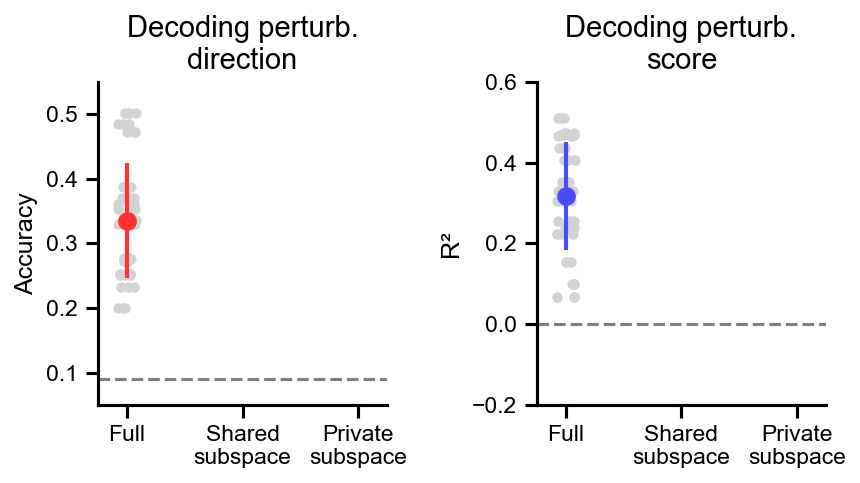

Saved: ../../results/pdfs/private_shared_frame2_shared.pdf


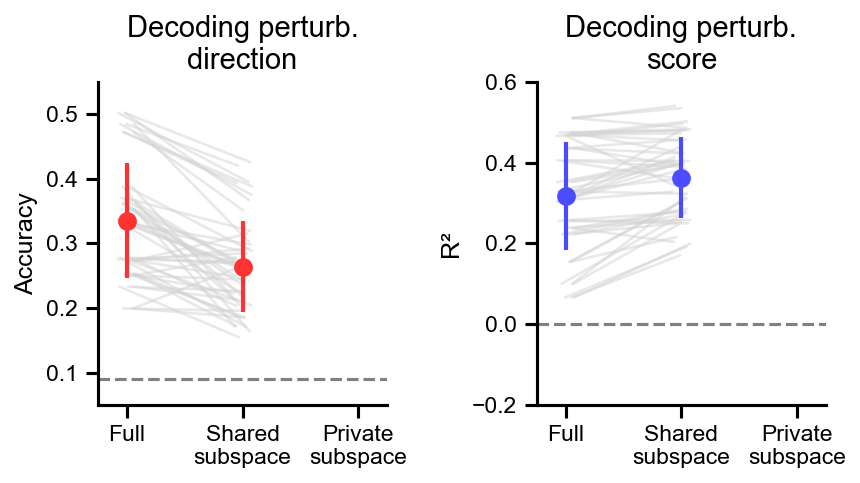

Saved: ../../results/pdfs/private_shared_frame3_private.pdf


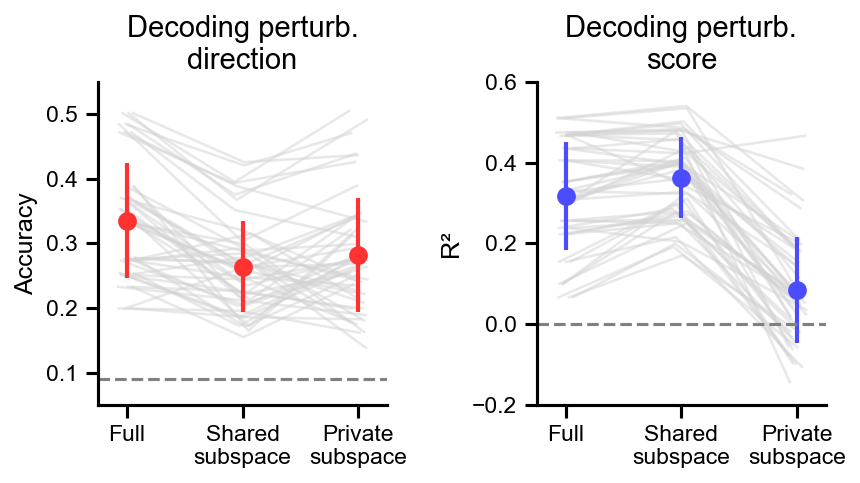

In [34]:
# ── progressive reveal plots for presentation ─────────────────────────────────
import matplotlib as mpl
bwr    = mpl.colormaps['bwr']
C_DIR  = bwr(0.9)
C_DIST = bwr(0.15)

mean_chance    = np.mean(all_chances)
all_lines_dist = np.array(all_lines_dist)
all_lines_dir  = np.array(all_lines_dir)
_xlbls = ['Full', 'Shared\nsubspace', 'Private\nsubspace']
_xpos  = np.arange(len(_xlbls))

# ── compute fixed y-limits from the full data so all frames are identical ─────
grand_mean_dist = all_lines_dist.mean(axis=0)
grand_std_dist  = all_lines_dist.std(axis=0)
grand_mean_dir  = all_lines_dir.mean(axis=0)
grand_std_dir   = all_lines_dir.std(axis=0)

_ylim_dist = (-0.2, 0.6)
_ylim_dir = (0.05, 0.55)   # fixed as in original

_rng = np.random.default_rng(seed=0)

_PDF_DIR = Path('../../results/pdfs')

def _draw_frame(n_cols_shown, show_lines, ylim_dist=None, ylim_dir=None, save_name=None):
    """Draw a 1×2 figure showing only the first n_cols_shown x-positions.

    Parameters
    ----------
    n_cols_shown : int        1 = Full only, 2 = Full+Shared, 3 = all three
    show_lines   : bool       whether to draw the gray per-pair connecting lines
    ylim_dist    : tuple|None y-limits for the disturbance panel (None = auto)
    ylim_dir     : tuple|None y-limits for the direction panel  (None = auto)
    save_name    : str|None   if given, save to results/pdfs/<save_name>.pdf
    """
    xpos_vis = _xpos[:n_cols_shown]

    with rc_context_talk():
        fig, axs = plt.subplots(1, 2, figsize=(6, 3.5))

        for ax, lines, ref_line, ylabel, title, c, ylim in [
            (axs[0], all_lines_dir,  0.09,  'Accuracy', 'Decoding perturb.\ndirection', C_DIR,  ylim_dir),
            (axs[1], all_lines_dist, 0,     'R²',       'Decoding perturb.\nscore',     C_DIST, ylim_dist),
        ]:
            vis = lines[:, :n_cols_shown]
            jitter = _rng.uniform(-0.08, 0.08, size=(vis.shape[0], n_cols_shown))

            if show_lines and n_cols_shown > 1:
                for row, jit in zip(vis, jitter):
                    ax.plot(xpos_vis + jit, row, '-', color='lightgray',
                            zorder=1, alpha=0.5, lw=1.25)
            else:
                for row, jit in zip(vis, jitter):
                    ax.plot(xpos_vis + jit, row, 'o', color='lightgray',
                            zorder=1, alpha=1, markersize=4)

            grand_mean = lines.mean(axis=0)[:n_cols_shown]
            grand_std  = lines.std(axis=0)[:n_cols_shown]
            ax.errorbar(xpos_vis, grand_mean, yerr=grand_std,
                        fmt='o', color=c, markersize=8, capsize=0,
                        linewidth=2, zorder=2)

            ax.axhline(ref_line, color='gray', linestyle='dashed', linewidth=1.5)

            ax.set_xticks(_xpos)
            ax.set_xlim((-0.25, 2.25))
            ax.set_xticklabels(_xlbls)
            ax.set_ylabel(ylabel)
            ax.set_title(title)
            if ylim is not None:
                ax.set_ylim(ylim)

        plt.tight_layout()

        if save_name is not None:
            out = _PDF_DIR / f'{save_name}.pdf'
            fig.savefig(out, bbox_inches='tight')
            print(f'Saved: {out}')

        plt.show()

# Frame 1 – Full only, dots
_draw_frame(n_cols_shown=1, show_lines=False, save_name='private_shared_frame1_full',
ylim_dir=_ylim_dir, ylim_dist=_ylim_dist)

# Frame 2 – Full + Shared, lines connecting
_draw_frame(n_cols_shown=2, show_lines=True, save_name='private_shared_frame2_shared',
ylim_dir=_ylim_dir, ylim_dist=_ylim_dist)

# Frame 3 – all three, lines connecting
_draw_frame(n_cols_shown=3, show_lines=True, save_name='private_shared_frame3_private',
ylim_dir=_ylim_dir, ylim_dist=_ylim_dist)

n_sess = len(all_sess_pot_null_vm)
# print(f"Total lines: {len(all_lines_dist)} ({n_sess} sessions × 12 area pairs)")